In [1]:
def evaluate_parameters_for_cmaes(theta, r_n, sim, sampler, L, target_node_idx, input_dims, 
                                   t_span, num_points, int_method, r_tol, a_tol, 
                                   precomputed_derivatives, C0, beta, eps = 1e-8, optimize_l0=False):
    """
    Evaluate a set of parameters for CMA-ES optimization.
    
    Parameters:
    -----------
    theta : np.ndarray
        Flattened parameter vector containing [E_list, B_list, F_list, log10(default_l0)]
    r_n : ReactionNetwork
        The reaction network object to update
    sim : ReactionNetworkSimulator
        The simulator object (should be pre-initialized)
    sampler : AdaptiveSampler (or similar)
        The sampler object for generating sign conditions
    L : np.ndarray
        Conservation law matrix
    target_node_idx : int
        Index of the target species
    input_dims : list
        Input dimension indices
    t_span : tuple
        Time span for simulation
    num_points : int
        Number of time points
    int_method : str
        Integration method
    r_tol : float
        Relative tolerance
    a_tol : float
        Absolute tolerance
    precomputed_derivatives : tuple
        Precomputed derivative functions
    C0 : float
        Reference concentration
    beta : float
        Inverse temperature parameter
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'sign_conditions': sign condition array
        - 'C_full_list': list of concentration vectors
        - 'dC_dl_list': list of sensitivity matrices
        - 'l0_list': list of initial concentrations used
        - 'C_target': concentrations at target node
        - 'dC_dl_target': sensitivities at target node
        - 'success': bool indicating if evaluation succeeded
    """
    
    n_species = r_n.n_species
    n_reactions = int(r_n.n_reactions / 2)
    n_cons = len(L)
    

    # Unflatten parameters
    E_list = theta[:n_species]
    B_list = theta[n_species:n_species+n_reactions]
    F_list = theta[n_species+n_reactions:n_species+2*n_reactions]

    if optimize_l0:
        default_l0_log = theta[n_species+2*n_reactions:]
        sampler.default_l0 = 10**default_l0_log
    
    # Update reaction rates
    reac_rates = get_rates_from_exponents(r_n, E_list, B_list, F_list, C0, beta)
    r_n.update_rates(reac_rates)
    
    # Update sampler's default initial concentrations
    sampler.default_l0 = default_l0
    
    # Sample sign conditions
    sign_conditions, C_full_list, dC_dl_list, l0_list, sample_count, convergence_reached = sampler.sample_sign_conditions(
        sim=sim,
        L=L,
        t_span=t_span,
        num_points=num_points,
        int_method=int_method,
        r_tol=r_tol,
        a_tol=a_tol,
        precomputed_derivatives=precomputed_derivatives
    )
    
    # Reset sampler for next evaluation
    sampler.reset()
    
    # Extract target node data
    C_target = [C_full[target_node_idx] for C_full in C_full_list]
    dC_dl_target = [dC_dl[target_node_idx, input_dims[0]] for dC_dl in dC_dl_list]
    log_l0_target = np.array([np.log10(l0[0]) for l0 in l0_list])

    d_vals = dC_dl_target
    C_vals = C_target
        
    # Find sign changes
    sign_change_indices = []
    for i in range(len(d_vals) - 1):
        if (d_vals[i] * d_vals[i + 1] < 0) and (np.abs(d_vals[i] - d_vals[i+1]) > eps):  # Sign change occurs
            sign_change_indices.append(i)
    
    critical_points = len(sign_change_indices)
    tac = total_absolute_curvatures(log_l0_target, C_target)
    arc_length = normalized_arc_length(log_l0_target, C_target)
    
    return {
        'C_full_list': C_full_list,
        'dC_dl_list': dC_dl_list,
        'C_target': C_target,
        'dC_dl_target': dC_dl_target,
        'log_l0_target': log_l0_target,
        'l0_list': l0_list,
        'critical_points': critical_points,
        'tac': tac,
        'arc_length': arc_length
    }
        

def create_initial_theta(n_species, n_reactions, n_cons, E_range, B_range, F_range, l0_range, optimize_l0=False):
    """
    Create an initial parameter vector for CMA-ES.
    
    Parameters:
    -----------
    n_species : int
        Number of species
    n_reactions : int
        Number of reactions (forward reactions only)
    n_cons : int
        Number of conservation laws
    E_range : float
        Range for E exponents
    B_range : float
        Range for B exponents
    F_range : float
        Range for F exponents
    l0_range : tuple
        (min, max) range for initial concentrations
    
    Returns:
    --------
    np.ndarray : Initial parameter vector
    """
    E_list = np.random.uniform(-E_range, E_range, n_species)
    B_list = np.random.uniform(-B_range, B_range, n_reactions)
    F_list = np.random.uniform(-F_range, F_range, n_reactions)
    
    if optimize_l0:
        l0_log = np.random.uniform(np.log10(l0_range[0]), np.log10(l0_range[1]), n_cons)
        theta = np.concatenate([E_list, B_list, F_list, l0_log])
    else:
        theta = np.concatenate([E_list, B_list, F_list])
    
    return theta


In [2]:
from CRNs import *
import numpy as np
import argparse
import time
import copy
import pickle


seed = 40
np.random.seed(seed)
random.seed(seed)

### Signaling network 
NR = 1
p_r = 0
# Convert string to list of integers
NS_vec = [6,1]
NS = sum(NS_vec)
target_node = 'S'+str(NS-1)

E_range = 6.0
B_range = 6.0
F_range = 6.0
C0 = 1
beta = 1
l0_range = (1e-9, 1e9)
l0_range_sub = (1e0, 1e0)


t_span = (0, 10000)
num_points = 10000
int_method = 'LSODA'
r_tol = 1e-12  
a_tol = 1e-12


if seed is not None:
    np.random.seed(seed)
    random.seed(seed)

#species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=False, include_uncatalyzed=True)
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
target_node = 'S'+str(NS-1)
target_node_idx = species_names.index(target_node)

print("Number of paths is", len(count_simple_paths(G, 'R0', target_node)))

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=seed,
    species_names=species_names,
    force_reverse=True
)
n_species = r_n.n_species
n_complexes = r_n.n_complexes
n_reactions = int(r_n.n_reactions / 2)
n_lcs = r_n.n_lcs
n_cons = len(L)
r_n_base = r_n

sim = ReactionNetworkSimulator(r_n)
reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
precomputed_derivatives = (dR_dC_func, dR_dl_func)

input_dims = [0]
default_l0 = np.ones(NR+NS)
sc_grad_dims = [[NR+NS-1],[0]]


profiler = TimeProfiler()
profiler.start_total_timer()

sampler = GridSampler(
    input_dims=input_dims,
    default_l0=default_l0,
    sc_grad_dims=sc_grad_dims,
    l0_range=l0_range,
    l0_grid_size=100,
    grid_dim=1,
    timeout_seconds=5,
    profiler=profiler,
    round_decimals=6,
    use_signal_alarms=False,
    use_contour_integration=True
)


sampler.default_l0 = default_l0
optimize_l0 = False




Number of paths is 6


In [3]:
import cma
import numpy as np

# --- 1. Define the objective function for CMA-ES (minimize negative) ---
def function_to_optimize(theta):
    results = evaluate_parameters_for_cmaes(theta, r_n, sim, sampler, L, target_node_idx, input_dims, 
                                        t_span, num_points, int_method, r_tol, a_tol, 
                                        precomputed_derivatives, C0, beta, optimize_l0=optimize_l0)
    return -results['critical_points'] - 0.2*results['tac'][1] - 5* (results['arc_length']-1)
    #return -results['tac'][1]
    
# --- 2. Initialize CMA-ES parameters ---
if optimize_l0:
    N = n_species + 2*n_reactions + n_cons  # full dimensionality
else:
    N = n_species + 2*n_reactions  # without l0

print(f"Optimization dimension: {N}")
print(f"  n_species: {n_species}")
print(f"  n_reactions: {n_reactions}")
if optimize_l0:
    print(f"  n_cons: {n_cons}")
else:
    print(f"  Optimizing l0: No (using fixed l0 = {sampler.default_l0})")

# Create initial mean from a random initialization
x0 = create_initial_theta(n_species, n_reactions, n_cons, E_range, B_range, F_range, l0_range, optimize_l0=optimize_l0)
sigma0 = 1.0  # initial step size

# CMA-ES options
if optimize_l0:
    bounds = [
        # Lower bounds
        [-E_range] * n_species + [-B_range] * n_reactions + [-F_range] * n_reactions + [np.log10(l0_range[0])] * n_cons,
        # Upper bounds
        [E_range] * n_species + [B_range] * n_reactions + [F_range] * n_reactions + [np.log10(l0_range[1])] * n_cons
    ]
else:
    bounds = [
        # Lower bounds
        [-E_range] * n_species + [-B_range] * n_reactions + [-F_range] * n_reactions,
        # Upper bounds
        [E_range] * n_species + [B_range] * n_reactions + [F_range] * n_reactions
    ]

options = {
    'popsize': 50,
    'maxiter': 20,
    'verb_disp': 1,
    'seed': seed,
    'tolfun': 1e-12,
    'tolx': 1e-12,
    'bounds': bounds
}

print(f"Population size: {options['popsize']}")

# --- 3. Create the CMA-ES object ---
es = cma.CMAEvolutionStrategy(x0, sigma0, options)

# --- 4. Optimization loop ---
best_value = -np.inf
best_theta = x0.copy()
no_improve = 0
iteration = 0

start_time = time.time()

while not es.stop():
    iteration += 1
    
    # Sample candidate parameter vectors
    solutions = es.ask()
    
    # Evaluate each candidate
    values = []
    for x in solutions:
        try:
            val = function_to_optimize(x)
            values.append(val)
        except Exception as e:
            print(f"  Warning: Evaluation failed, assigning penalty. Error: {e}")
            values.append(1e10)  # large penalty for failed evaluations
    
    # Update the CMA-ES internal state
    es.tell(solutions, values)
    es.disp()
    
    # Track best solution (remember, we're minimizing -f)
    current_best = -min(values)
    if current_best > best_value:
        best_value = current_best
        best_theta = solutions[np.argmin(values)].copy()
        no_improve = 0
        print(f"  ✓ New best: {best_value}")
    else:
        no_improve += 1
    
    # If we haven't improved for a while, re-expand search radius
    if no_improve > 15:
        print("🔁 Re-expanding search radius...")
        es.sigma *= 2.0
        no_improve = 0
    
    # Print progress every 10 iterations
    if iteration % 10 == 0:
        elapsed = time.time() - start_time
        print(f"\n=== Iteration {iteration} | Best so far: {best_value} | Elapsed: {elapsed:.1f}s ===\n")

end_time = time.time()

# Display final results
es.result_pretty()

# --- 5. Results ---
print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)
print(f"Best θ found: {best_theta}")
print(f"Max # of critical points: {best_value}")
print(f"Total time: {end_time - start_time:.2f} seconds")
print("="*60)

# Verify the best solution
print("\nVerifying best solution...")
final_critical_points = function_to_optimize(best_theta)
print(f"Verification: {final_critical_points} critical points")

# Save the best parameters
best_params = {
    'theta': best_theta,
    'critical_points': best_value,
    'E_list': best_theta[:n_species],
    'B_list': best_theta[n_species:n_species+n_reactions],
    'F_list': best_theta[n_species+n_reactions:n_species+2*n_reactions],
    'l0_log': best_theta[n_species+2*n_reactions:],
    'l0': 10**best_theta[n_species+2*n_reactions:],
}

print("\nBest parameters breakdown:")
print(f"  E_list: {best_params['E_list']}")
print(f"  B_list: {best_params['B_list']}")
print(f"  F_list: {best_params['F_list']}")
print(f"  l0: {best_params['l0']}")

ModuleNotFoundError: No module named 'cma'

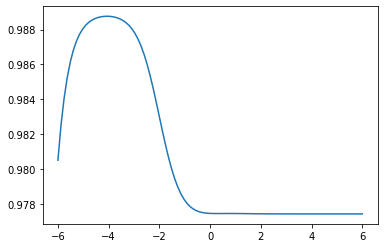

In [74]:
results = evaluate_parameters_for_cmaes(best_theta, r_n, sim, sampler, L, target_node_idx, input_dims, 
                                        t_span, num_points, int_method, r_tol, a_tol, 
                                        precomputed_derivatives, C0, beta, optimize_l0=optimize_l0)

import matplotlib.pyplot as plt
plt.plot(results['log_l0_target'], results['C_target'])
#plt.plot(results['dC_dl_target'] * results['log_l0_target'])

In [18]:
import emcee
import numpy as np
import time

# --- 1. Define the log-probability function for MCMC ---
def log_prior(theta):
    """Uniform prior within bounds"""
    if optimize_l0:
        E_vals = theta[:n_species]
        B_vals = theta[n_species:n_species+n_reactions]
        F_vals = theta[n_species+n_reactions:n_species+2*n_reactions]
        l0_log_vals = theta[n_species+2*n_reactions:]
        
        # Check bounds
        if (np.all(np.abs(E_vals) <= E_range) and 
            np.all(np.abs(B_vals) <= B_range) and 
            np.all(np.abs(F_vals) <= F_range) and
            np.all((l0_log_vals >= np.log10(l0_range[0])) & (l0_log_vals <= np.log10(l0_range[1])))):
            return 0.0  # log(1) = 0 for uniform prior
    else:
        E_vals = theta[:n_species]
        B_vals = theta[n_species:n_species+n_reactions]
        F_vals = theta[n_species+n_reactions:n_species+2*n_reactions]
        
        # Check bounds
        if (np.all(np.abs(E_vals) <= E_range) and 
            np.all(np.abs(B_vals) <= B_range) and 
            np.all(np.abs(F_vals) <= F_range)):
            return 0.0  # log(1) = 0 for uniform prior
    
    return -np.inf  # log(0) = -inf for out of bounds


def log_likelihood(theta, temp=1):
    """Convert objective function to log-likelihood"""
    try:
        results = evaluate_parameters_for_cmaes(
            theta, r_n, sim, sampler, L, target_node_idx, input_dims, 
            t_span, num_points, int_method, r_tol, a_tol, 
            precomputed_derivatives, C0, beta, optimize_l0=optimize_l0
        )
        
        # Original objective: maximize critical_points + 0.2*tac[1] + 5*(arc_length-1)
        objective_value = results['critical_points'] #+ 0.2*results['tac'][1] + 5*(results['arc_length']-1)
        
        # Convert to log-likelihood (scale for MCMC sampling)
        # Using a scaling factor to make the probabilities more reasonable
        #return (objective_value + 50*(results['arc_length']-1)) / temp # scale down to avoid numerical issues
        return (objective_value + 0*(results['tac'][1])) / temp # scale down to avoid numerical issues
        

    except Exception as e:
        print(f"  Warning: Evaluation failed for parameter set. Error: {e}")
        return -np.inf  # reject failed evaluations

def log_probability_temp(theta, temp=1):
    """Combined log-probability = log-prior + log-likelihood"""
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta, temp)
    if not np.isfinite(ll):
        return -np.inf
    return lp + ll

# --- 2. Initialize MCMC parameters ---
if optimize_l0:
    N = n_species + 2*n_reactions + n_cons  # full dimensionality
else:
    N = n_species + 2*n_reactions  # without l0

print(f"MCMC dimension: {N}")
print(f"  n_species: {n_species}")
print(f"  n_reactions: {n_reactions}")
if optimize_l0:
    print(f"  n_cons: {n_cons}")
else:
    print(f"  Optimizing l0: No (using fixed l0 = {sampler.default_l0})")

# MCMC settings
#n_walkers = 50      # number of MCMC walkers (similar to popsize in CMA-ES)
n_walkers = max(6 * N + 10, 100)  # At least 2*N, with a buffer
print(f"  Number of walkers: {n_walkers}")
n_steps = 30        # number of MCMC steps (similar to maxiter)
n_burn = 0          # burn-in steps to discard
temp = 50

print(f"\nMCMC Configuration:")
print(f"  Number of walkers: {n_walkers}")
print(f"  Number of steps: {n_steps}")
print(f"  Burn-in steps: {n_burn}")

def log_probability(theta):
    return log_probability_temp(theta, temp=temp)
    
# Initialize walkers around random starting positions
print("\nInitializing walkers...")
initial_positions = []
for i in range(n_walkers):
    theta_init = create_initial_theta(
        n_species, n_reactions, n_cons, E_range, B_range, F_range, 
        l0_range, optimize_l0=optimize_l0
    )
    initial_positions.append(theta_init)
initial_positions = np.array(initial_positions)
print(f"Initial positions shape: {initial_positions.shape}")

# --- 3. Create the MCMC sampler ---
print("\nCreating MCMC sampler...")
sampler_mcmc = emcee.EnsembleSampler(n_walkers, N, log_probability)

# --- 4. Run MCMC ---
print("\n" + "="*60)
print("STARTING MCMC SAMPLING")
print("="*60)
start_time = time.time()

seed = 42 
np.random.seed(seed)
random.seed(seed)


best_log_prob = -np.inf
best_theta = initial_positions[0].copy()
iteration_times = []

# Run the sampler with progress tracking
for i, result in enumerate(sampler_mcmc.sample(initial_positions, iterations=n_steps)):
    iteration = i + 1
    iter_start = time.time()
    
    pos = result.coords
    prob = result.log_prob
    
    # Track best solution
    max_prob_idx = np.argmax(prob)
    current_best_prob = prob[max_prob_idx]
    
    if current_best_prob > best_log_prob:
        best_log_prob = current_best_prob
        best_theta = pos[max_prob_idx].copy()
        print(f"  ✓ New best log-prob: {best_log_prob:.4f} at iteration {iteration}")
    
    iter_time = time.time() - iter_start
    iteration_times.append(iter_time)
    
    # Print progress
    if iteration % 5 == 0 or iteration == 1:
        mean_accept = np.mean(sampler_mcmc.acceptance_fraction[:iteration])
        elapsed = time.time() - start_time
        avg_iter_time = np.mean(iteration_times)
        eta = avg_iter_time * (n_steps - iteration)
        
        print(f"\n{'='*60}")
        print(f"Step {iteration}/{n_steps}")
        print(f"  Best log-prob: {temp * best_log_prob:.4f}")
        print(f"  Mean acceptance: {mean_accept:.3f}")
        print(f"  Avg iteration time: {avg_iter_time:.2f}s")
        print(f"  Elapsed: {elapsed:.1f}s | ETA: {eta:.1f}s")
        print(f"{'='*60}")

end_time = time.time()

# --- 5. Analyze results ---
print("\n" + "="*60)
print("MCMC SAMPLING COMPLETE")
print("="*60)

# Get samples after burn-in
samples = sampler_mcmc.get_chain(discard=n_burn, flat=True)
log_probs = sampler_mcmc.get_log_prob(discard=n_burn, flat=True)

print(f"\nSampling Statistics:")
print(f"  Total samples collected (after burn-in): {len(samples)}")
print(f"  Mean acceptance fraction: {np.mean(sampler_mcmc.acceptance_fraction):.3f}")
print(f"  Min acceptance fraction: {np.min(sampler_mcmc.acceptance_fraction):.3f}")
print(f"  Max acceptance fraction: {np.max(sampler_mcmc.acceptance_fraction):.3f}")
print(f"  Total time: {end_time - start_time:.2f} seconds")
print(f"  Avg time per step: {np.mean(iteration_times):.2f} seconds")

# Get MAP (Maximum A Posteriori) estimate
map_idx = np.argmax(log_probs)
map_theta = samples[map_idx]
map_log_prob = log_probs[map_idx]

print(f"\nBest θ (from sampling): {best_theta}")
print(f"Best log-probability: {best_log_prob:.4f}")

print(f"\nMAP estimate θ: {map_theta}")
print(f"MAP log-probability: {map_log_prob:.4f}")

# Get posterior statistics
mean_theta = np.mean(samples, axis=0)
std_theta = np.std(samples, axis=0)
median_theta = np.median(samples, axis=0)

print(f"\nPosterior Statistics:")
print(f"  Mean θ: {mean_theta}")
print(f"  Std θ: {std_theta}")
print(f"  Median θ: {median_theta}")

print("="*60)

# --- 6. Save results ---
best_params = {
    'theta_map': map_theta,
    'theta_best': best_theta,
    'theta_mean': mean_theta,
    'theta_median': median_theta,
    'theta_std': std_theta,
    'log_prob_map': map_log_prob,
    'log_prob_best': best_log_prob,
    'samples': samples,
    'log_probs': log_probs,
    'acceptance_fraction': sampler_mcmc.acceptance_fraction,
    'chain': sampler_mcmc.get_chain(discard=n_burn),
    'sampling_time': end_time - start_time,
}

# Extract parameters from MAP estimate
best_params['E_list_map'] = map_theta[:n_species]
best_params['B_list_map'] = map_theta[n_species:n_species+n_reactions]
best_params['F_list_map'] = map_theta[n_species+n_reactions:n_species+2*n_reactions]

# Extract parameters from best sample
best_params['E_list_best'] = best_theta[:n_species]
best_params['B_list_best'] = best_theta[n_species:n_species+n_reactions]
best_params['F_list_best'] = best_theta[n_species+n_reactions:n_species+2*n_reactions]

if optimize_l0:
    best_params['l0_log_map'] = map_theta[n_species+2*n_reactions:]
    best_params['l0_map'] = 10**map_theta[n_species+2*n_reactions:]
    best_params['l0_log_best'] = best_theta[n_species+2*n_reactions:]
    best_params['l0_best'] = 10**best_theta[n_species+2*n_reactions:]

print("\nMAP parameters breakdown:")
print(f"  E_list: {best_params['E_list_map']}")
print(f"  B_list: {best_params['B_list_map']}")
print(f"  F_list: {best_params['F_list_map']}")
if optimize_l0:
    print(f"  l0: {best_params['l0_map']}")

print("\nBest parameters breakdown:")
print(f"  E_list: {best_params['E_list_best']}")
print(f"  B_list: {best_params['B_list_best']}")
print(f"  F_list: {best_params['F_list_best']}")
if optimize_l0:
    print(f"  l0: {best_params['l0_best']}")

# Verify the best solution
print("\n" + "="*60)
print("VERIFYING BEST SOLUTION")
print("="*60)
verification_results = evaluate_parameters_for_cmaes(
    best_theta, r_n, sim, sampler, L, target_node_idx, input_dims, 
    t_span, num_points, int_method, r_tol, a_tol, 
    precomputed_derivatives, C0, beta, optimize_l0=optimize_l0
)
print(f"Critical points: {verification_results['critical_points']}")
print(f"TAC: {verification_results['tac']}")
print(f"Arc length: {verification_results['arc_length']}")
print(f"Objective value: {verification_results['critical_points'] + 0.2*verification_results['tac'][1] + 5*(verification_results['arc_length']-1):.4f}")
print("="*60)


MCMC dimension: 53
  n_species: 15
  n_reactions: 19
  Optimizing l0: No (using fixed l0 = [1. 1. 1. 1. 1. 1. 1. 1.])
  Number of walkers: 328

MCMC Configuration:
  Number of walkers: 328
  Number of steps: 30
  Burn-in steps: 0

Initializing walkers...
Initial positions shape: (328, 53)

Creating MCMC sampler...

STARTING MCMC SAMPLING
  ✓ New best log-prob: 0.0600 at iteration 1

Step 1/30
  Best log-prob: 3.0000
  Mean acceptance: 0.000
  Avg iteration time: 0.00s
  Elapsed: 79.5s | ETA: 0.0s

Step 5/30
  Best log-prob: 3.0000
  Mean acceptance: 0.000
  Avg iteration time: 0.00s
  Elapsed: 166.0s | ETA: 0.0s

Step 10/30
  Best log-prob: 3.0000
  Mean acceptance: 0.020
  Avg iteration time: 0.00s
  Elapsed: 281.2s | ETA: 0.0s

Step 15/30
  Best log-prob: 3.0000
  Mean acceptance: 0.027
  Avg iteration time: 0.00s
  Elapsed: 393.3s | ETA: 0.0s

Step 20/30
  Best log-prob: 3.0000
  Mean acceptance: 0.028
  Avg iteration time: 0.00s
  Elapsed: 510.5s | ETA: 0.0s

Step 25/30
  Best log-

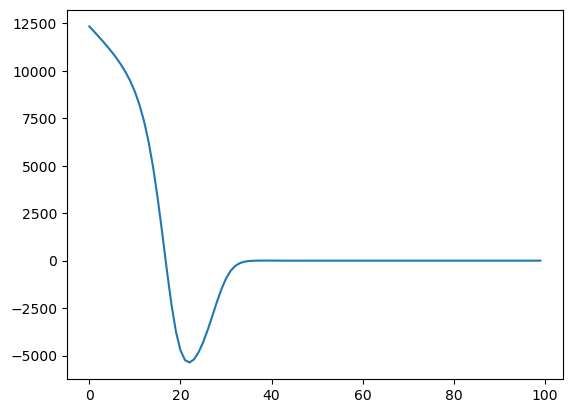

In [19]:
results = evaluate_parameters_for_cmaes(best_theta, r_n, sim, sampler, L, target_node_idx, input_dims, 
                                        t_span, num_points, int_method, r_tol, a_tol, 
                                        precomputed_derivatives, C0, beta, optimize_l0=optimize_l0)

import matplotlib.pyplot as plt
#plt.plot(results['log_l0_target'], results['C_target'])
plt.plot(results['dC_dl_target'] * results['log_l0_target'])
#plt.axhline(0, color='gray', linestyle='--')
ed = 0.1
#plt.ylim(-ed, ed)
plt.show()
